# Three-Model Monocular Metric Depth Comparison
## Depth-Anything-V2 vs ZoeDepth vs Depth Pro

This notebook presents a controlled monocular metric-depth benchmark comparing Depth-Anything-V2, ZoeDepth, and Depth Pro under a common evaluation protocol.

Metric depth estimation is important in AI and robotics for applications such as navigation, obstacle avoidance, scene understanding, and spatial perception. A controlled comparison is therefore useful for understanding which model provides the best balance of metric accuracy, depth consistency, and computational efficiency.

All three models are evaluated using the same **59 synchronized RGB-depth pairs**, captured with an Intel RealSense depth camera in a real indoor lab environment. The RGB frame is the sole input to every model; the RealSense depth map is dense, per-pixel ground truth, stored in millimeters and converted to meters (`x 0.001`), and is never passed to any model during inference. The comparison reports pixel-wise MAE, RMSE, and Abs Rel, image-level median-depth error, prediction consistency, inference latency, and model size.

The goal is to identify the accuracy–efficiency trade-offs of the three models under identical experimental conditions. Depth Pro uses its official inference pipeline, while Depth-Anything-V2 and ZoeDepth use their respective Hugging Face implementations.


## Experimental Design

The dataset is **59 real RGB-depth pairs** captured with an Intel RealSense depth camera in a lab environment. Each RealSense depth map is dense, per-pixel ground truth for its matching RGB frame, converted from millimeters to meters and with zero-valued (invalid) pixels excluded from every metric.

The ground truth is never passed to any model during inference — it is used only afterward, to score the predicted depth maps.

For each frame, the common quantitative metrics are:

- MAE (m)
- RMSE (m)
- Abs Rel (%)
- Median depth error (m)
- Predicted depth standard deviation (m)
- Mean inference latency (ms)
- Median inference latency (ms)
- Latency standard deviation (ms)

The median predicted depth is retained as an image-level summary statistic because it is less sensitive to isolated outlier pixels than the mean, alongside the dense pixel-wise metrics above.


### Runtime-separation design

Depth-Anything-V2/ZoeDepth and Depth Pro are executed in separate environments. Before the runtime restart, the notebook serializes the complete experimental state required for comparison using `pickle`. Live model and processor objects are deliberately excluded because they are environment-specific; after restart, only the Depth Pro model is loaded while the previously measured DA/Zoe results and depth maps are restored exactly from the saved state.


In [ ]:
!pip install -q -U huggingface_hub transformers

In [ ]:
import gc
import time
import platform
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch

from PIL import Image
from huggingface_hub import hf_hub_download
from IPython.display import display

from transformers import AutoImageProcessor, AutoModelForDepthEstimation, ZoeDepthForDepthEstimation
from pathlib import Path
import pickle
import json


In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch:", torch.__version__)
print("Python:", platform.python_version())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

STATE_DIR = Path("/content/metric_depth_saved_state")
STATE_DIR.mkdir(parents=True, exist_ok=True)
STATE_PATH = STATE_DIR / "metric_depth_experiment_state.pkl"

print("Persistent state path:", STATE_PATH)


## 1. Common Dataset Configuration

The dataset is **59 synchronized RGB-depth pairs** captured with an Intel RealSense depth camera in a real indoor lab environment, packaged as a single zip archive and hosted on the public Hugging Face dataset repository. The archive is downloaded and extracted once, and its `color/` and `depth/` folders are checked for alignment before any inference is run.

**Do not create separate image loaders for the models.** Every model receives the same `available_cases` objects, and every model is scored against the same RealSense depth map for its frame.


In [ ]:
HF_REPO = "WasiqSaleem/Portfolio_Assets"
HF_REPO_TYPE = "dataset"
ZIP_NAME = "testing_env_spec_real_camera_dataset_combined.zip"
DATASET_FOLDER = "testing_env_spec_real_camera_dataset_combined"  # top-level folder inside the zip
COLOR_SUBDIR = "color"
DEPTH_SUBDIR = "depth"

# RealSense depth PNGs are stored in millimeters -> convert to meters.
DEPTH_UNITS_TO_METERS = 0.001

In [ ]:
zip_path = hf_hub_download(
    repo_id=HF_REPO,
    filename=ZIP_NAME,
    repo_type=HF_REPO_TYPE,
    local_dir="/content"
)

extract_root = Path("/content")
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_root)

dataset_root = extract_root / DATASET_FOLDER
color_dir = dataset_root / COLOR_SUBDIR
depth_dir = dataset_root / DEPTH_SUBDIR

color_paths = sorted(color_dir.glob("*.png"))
depth_paths = sorted(depth_dir.glob("*.png"))

assert len(color_paths) == len(depth_paths), (
    f"Mismatched pair counts: {len(color_paths)} color vs {len(depth_paths)} depth"
)
assert all(c.stem == d.stem for c, d in zip(color_paths, depth_paths)), (
    "Color and depth filenames are not aligned by stem."
)

available_cases = []

for color_path, depth_path in zip(color_paths, depth_paths):
    image = Image.open(color_path).convert("RGB")

    available_cases.append({
        "image_number": color_path.stem,
        "filename": color_path.name,
        "image_path": color_path,
        "depth_path": depth_path,
        "image": image
    })

print(f"Loaded {len(available_cases)} aligned RGB-depth pairs.")

sample_case = available_cases[0]
raw_depth = np.array(Image.open(sample_case["depth_path"]), dtype=np.float32)
converted_depth = raw_depth * DEPTH_UNITS_TO_METERS
valid_converted = converted_depth[converted_depth > 0]
print(f"Sample frame: {sample_case['image_number']}")
print(f"Raw depth range (mm): {raw_depth.min():.0f} - {raw_depth.max():.0f}")
print(f"Converted depth range (m, valid pixels only): {valid_converted.min():.3f} - {valid_converted.max():.3f}")


In [ ]:
sample_indices = np.linspace(0, len(available_cases) - 1, 6).round().astype(int)
sample_cases = [available_cases[i] for i in sample_indices]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.ravel(), sample_cases):
    ax.imshow(case["image"])
    ax.set_title(f"Frame {case['image_number']}")
    ax.axis("off")
plt.suptitle("Sampled RGB Frames")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.ravel(), sample_cases):
    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    gt_display = np.ma.masked_where(gt_depth <= 0, gt_depth)
    ax.imshow(gt_display, cmap="magma")
    ax.set_title(f"Frame {case['image_number']} (GT)")
    ax.axis("off")
plt.suptitle("Sampled RealSense Ground-Truth Depth Maps (m)")
plt.tight_layout()
plt.show()


## 2. Common Evaluation and Benchmarking Functions

All three models are evaluated with the same statistical definitions, computed **pixel-wise** over the valid, overlapping region between the predicted depth map and the RealSense ground-truth depth map (zero/invalid GT pixels excluded):

$$MAE = \text{mean}(|\hat d - d_{GT}|)$$

$$RMSE = \sqrt{\text{mean}((\hat d - d_{GT})^2)}$$

$$\text{AbsRel} = \text{mean}\left(\frac{|\hat d - d_{GT}|}{d_{GT}}\right)\times100$$

The median predicted depth is also retained as an image-level summary statistic.

Latency is measured after warm-up using repeated runs. CUDA synchronization is used where applicable so GPU timings are not dominated by asynchronous execution.


In [ ]:
def evaluate_depth(depth_map, ground_truth):
    depth_map = np.asarray(depth_map, dtype=np.float32)
    ground_truth = np.asarray(ground_truth, dtype=np.float32)

    valid = (
        np.isfinite(depth_map) & np.isfinite(ground_truth)
        & (depth_map > 0) & (ground_truth > 0)
    )

    pred = depth_map[valid]
    gt = ground_truth[valid]

    if pred.size == 0:
        raise ValueError("No valid overlapping pixels between prediction and ground truth.")

    error = np.abs(pred - gt)

    return {
        "GT Median (m)": float(np.median(gt)),
        "Pred Median (m)": float(np.median(pred)),
        "Pred Mean (m)": float(np.mean(pred)),
        "Std Depth (m)": float(np.std(pred)),
        "MAE (m)": float(np.mean(error)),
        "RMSE (m)": float(np.sqrt(np.mean((pred - gt) ** 2))),
        "Abs Rel (%)": float(np.mean(error / gt) * 100),
        "Median Absolute Error (m)": float(np.median(error)),
        "Valid Pixels (%)": float(valid.mean() * 100),
    }


def benchmark(fn, warmup=3, runs=10):
    for _ in range(warmup):
        fn()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []

    for _ in range(runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()
        fn()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        times.append(time.perf_counter() - start)

    return {
        "mean_ms": float(np.mean(times) * 1000),
        "median_ms": float(np.median(times) * 1000),
        "std_ms": float(np.std(times) * 1000),
        "min_ms": float(np.min(times) * 1000),
        "max_ms": float(np.max(times) * 1000),
    }


def parameter_count(model):
    return int(sum(p.numel() for p in model.parameters()))


def parameter_count_millions(model):
    return parameter_count(model) / 1e6


def model_vram_gb():
    if torch.cuda.is_available():
        return float(torch.cuda.memory_allocated() / 1e9)
    return np.nan


# Part A — Model Loading

The checkpoint used for each model is explicitly recorded. The models are not altered, fine-tuned, or calibrated against the test ground truth.


In [ ]:
MODEL_CONFIG = {
    "Depth-Anything-V2": {
        "checkpoint": "depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf",
        "task": "Metric monocular depth — indoor small"
    },
    "ZoeDepth-NYU": {
        "checkpoint": "Intel/zoedepth-nyu",
        "task": "Metric monocular depth — NYU indoor"
    },
    "Depth Pro": {
        "checkpoint": "apple/DepthPro",
        "task": "Zero-shot metric monocular depth"
    }
}

display(pd.DataFrame(MODEL_CONFIG).T)


## 3. Depth-Anything-V2

Checkpoint: `depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf`

The Hugging Face processor/model interface is used, matching the supplied Depth-Anything-V2 notebook.


In [ ]:
da_processor = AutoImageProcessor.from_pretrained(
    MODEL_CONFIG["Depth-Anything-V2"]["checkpoint"]
)

da_model = AutoModelForDepthEstimation.from_pretrained(
    MODEL_CONFIG["Depth-Anything-V2"]["checkpoint"]
).to(device).eval()

print("Loaded:", MODEL_CONFIG["Depth-Anything-V2"]["checkpoint"])
print("Parameters (M):", parameter_count_millions(da_model))


In [ ]:
da_results = []
da_depth_maps = {}

for case in available_cases:

    def run_da():
        inputs = da_processor(
            images=case["image"],
            return_tensors="pt"
        )
        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.inference_mode():
            outputs = da_model(**inputs)

        depth = da_processor.post_process_depth_estimation(
            outputs,
            target_sizes=[
                (case["image"].height, case["image"].width)
            ]
        )[0]["predicted_depth"]

        return depth.squeeze().detach().cpu().numpy()

    timing = benchmark(run_da, warmup=3, runs=10)
    depth = run_da()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)

    metrics = evaluate_depth(depth, gt_depth)

    da_depth_maps[case["image_number"]] = depth

    da_results.append({
        "Model": "Depth-Anything-V2",
        "Image": case["image_number"],
        "Filename": case["filename"],
        **metrics,
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
        "Latency Std (ms)": timing["std_ms"],
        "Min Latency (ms)": timing["min_ms"],
        "Max Latency (ms)": timing["max_ms"],
    })

da_df = pd.DataFrame(da_results)
display(da_df.round(4))


## 4. ZoeDepth-NYU

Checkpoint: `Intel/zoedepth-nyu`

The same images, ground-truth distances, evaluation function, and latency benchmark are used. Only the model-specific preprocessing and forward/post-processing implementation differ.


In [ ]:
zoe_processor = AutoImageProcessor.from_pretrained(
    MODEL_CONFIG["ZoeDepth-NYU"]["checkpoint"]
)

zoe_model = ZoeDepthForDepthEstimation.from_pretrained(
    MODEL_CONFIG["ZoeDepth-NYU"]["checkpoint"]
).to(device).eval()

print("Loaded:", MODEL_CONFIG["ZoeDepth-NYU"]["checkpoint"])
print("Parameters (M):", parameter_count_millions(zoe_model))


In [ ]:
zoe_results = []
zoe_depth_maps = {}

for case in available_cases:

    def run_zoe():
        inputs = zoe_processor(
            images=case["image"],
            return_tensors="pt"
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.inference_mode():
            outputs = zoe_model(**inputs)

        image_size = (
            case["image"].height,
            case["image"].width
        )

        processed = zoe_processor.post_process_depth_estimation(
            outputs,
            source_sizes=[image_size],
            target_sizes=[image_size]
        )

        depth = processed[0]["predicted_depth"]

        return depth.squeeze().detach().cpu().numpy()

    timing = benchmark(run_zoe, warmup=3, runs=10)
    depth = run_zoe()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)

    metrics = evaluate_depth(depth, gt_depth)

    zoe_depth_maps[case["image_number"]] = depth

    zoe_results.append({
        "Model": "ZoeDepth-NYU",
        "Image": case["image_number"],
        "Filename": case["filename"],
        **metrics,
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
        "Latency Std (ms)": timing["std_ms"],
        "Min Latency (ms)": timing["min_ms"],
        "Max Latency (ms)": timing["max_ms"],
    })

zoe_df = pd.DataFrame(zoe_results)
display(zoe_df.round(4))


# 5. Save Experimental State Before Runtime Restart

The Hugging Face and Depth Pro environments may require different dependency stacks.
Therefore, the completed results from Environment 1 are serialized before restarting.

**Important:** live model/processor objects are intentionally not pickled. They are environment-specific and are re-created after restart. All experimental data needed for the comparison is saved: configuration, image cases, downloaded RGB images, depth maps, per-image results, dataframes, seeds, and measured parameter counts.


In [ ]:
hf_state = {
    "state_version": 1,
    "seed": SEED,
    "HF_REPO": HF_REPO,
    "HF_REPO_TYPE": HF_REPO_TYPE,
    "ZIP_NAME": ZIP_NAME,
    "DATASET_FOLDER": DATASET_FOLDER,
    "COLOR_SUBDIR": COLOR_SUBDIR,
    "DEPTH_SUBDIR": DEPTH_SUBDIR,
    "DEPTH_UNITS_TO_METERS": DEPTH_UNITS_TO_METERS,
    "MODEL_CONFIG": MODEL_CONFIG,
    "available_cases": available_cases,
    "da_results": da_results,
    "da_depth_maps": da_depth_maps,
    "da_df": da_df,
    "zoe_results": zoe_results,
    "zoe_depth_maps": zoe_depth_maps,
    "zoe_df": zoe_df,
    "parameter_counts": {
        "Depth-Anything-V2": parameter_count(da_model),
        "ZoeDepth-NYU": parameter_count(zoe_model),
    },

    "environment_1": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "device": str(device),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
}

with open(STATE_PATH, "wb") as f:
    pickle.dump(hf_state, f, protocol=pickle.HIGHEST_PROTOCOL)

state_size_mb = STATE_PATH.stat().st_size / (1024 ** 2)

print("State saved successfully.")
print("Path:", STATE_PATH)
print(f"Size: {state_size_mb:.2f} MB")
print("Saved:")
for key in hf_state:
    print("  -", key)
del da_model, da_processor, zoe_model, zoe_processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("Environment-1 model objects released. Restart the runtime now.")


## 5. Depth Pro

Checkpoint: Apple `DepthPro` (`apple/DepthPro`).

Depth Pro has a model-specific official preprocessing/inference interface. The RGB images and evaluation protocol remain identical.


In [ ]:
!rm -rf /content/ml-depth-pro
!git clone -q https://github.com/apple/ml-depth-pro.git
%cd /content/ml-depth-pro
!pip install -q -e .
!pip install -q "numpy>=2.0,<2.3"
%cd /content
# RESTART THE RUNTIME AND RUN AGAIN FROM BELOW CELL

In [ ]:
!mkdir -p checkpoints
!hf download apple/DepthPro depth_pro.pt --local-dir checkpoints
!ls -lh checkpoints/depth_pro.pt
%cd /content/ml-depth-pro

In [ ]:
!huggingface-cli download --local-dir checkpoints apple/DepthPro
%cd ..

In [ ]:
import gc
import time
import platform
import zipfile
import depth_pro
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from PIL import Image
from IPython.display import display


In [ ]:
STATE_DIR = Path("/content/metric_depth_saved_state")
STATE_PATH = STATE_DIR / "metric_depth_experiment_state.pkl"

if not STATE_PATH.exists():
    raise FileNotFoundError(
        f"Saved state not found at {STATE_PATH}. "
        "Run the Environment-1 SAVE STATE cell before restarting."
    )

with open(STATE_PATH, "rb") as f:
    hf_state = pickle.load(f)

SEED = hf_state["seed"]
HF_REPO = hf_state["HF_REPO"]
HF_REPO_TYPE = hf_state["HF_REPO_TYPE"]
ZIP_NAME = hf_state["ZIP_NAME"]
DATASET_FOLDER = hf_state["DATASET_FOLDER"]
COLOR_SUBDIR = hf_state["COLOR_SUBDIR"]
DEPTH_SUBDIR = hf_state["DEPTH_SUBDIR"]
DEPTH_UNITS_TO_METERS = hf_state["DEPTH_UNITS_TO_METERS"]
MODEL_CONFIG = hf_state["MODEL_CONFIG"]
available_cases = hf_state["available_cases"]

da_results = hf_state["da_results"]
da_depth_maps = hf_state["da_depth_maps"]
da_df = hf_state["da_df"]

zoe_results = hf_state["zoe_results"]
zoe_depth_maps = hf_state["zoe_depth_maps"]
zoe_df = hf_state["zoe_df"]

saved_parameter_counts = hf_state["parameter_counts"]

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the helper functions because Python definitions disappear on restart.
def evaluate_depth(depth_map, ground_truth):
    depth_map = np.asarray(depth_map, dtype=np.float32)
    ground_truth = np.asarray(ground_truth, dtype=np.float32)

    valid = (
        np.isfinite(depth_map) & np.isfinite(ground_truth)
        & (depth_map > 0) & (ground_truth > 0)
    )

    pred = depth_map[valid]
    gt = ground_truth[valid]

    if pred.size == 0:
        raise ValueError("No valid overlapping pixels between prediction and ground truth.")

    error = np.abs(pred - gt)

    return {
        "GT Median (m)": float(np.median(gt)),
        "Pred Median (m)": float(np.median(pred)),
        "Pred Mean (m)": float(np.mean(pred)),
        "Std Depth (m)": float(np.std(pred)),
        "MAE (m)": float(np.mean(error)),
        "RMSE (m)": float(np.sqrt(np.mean((pred - gt) ** 2))),
        "Abs Rel (%)": float(np.mean(error / gt) * 100),
        "Median Absolute Error (m)": float(np.median(error)),
        "Valid Pixels (%)": float(valid.mean() * 100),
    }

def benchmark(fn, warmup=3, runs=10):
    for _ in range(warmup):
        fn()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.perf_counter() - start)

    return {
        "mean_ms": float(np.mean(times) * 1000),
        "median_ms": float(np.median(times) * 1000),
        "std_ms": float(np.std(times) * 1000),
        "min_ms": float(np.min(times) * 1000),
        "max_ms": float(np.max(times) * 1000),
    }

def parameter_count(model):
    return int(sum(p.numel() for p in model.parameters()))

def parameter_count_millions(model):
    return parameter_count(model) / 1e6

print("State restored successfully.")
print("Device:", device)
print("Environment 1:", hf_state["environment_1"])
print("Restored images:", len(available_cases))
print("Restored DA rows:", len(da_df))
print("Restored ZoeDepth rows:", len(zoe_df))


## Restored-State Verification

This checkpoint verifies that the same image cases and Environment-1 measurements are present before Depth Pro is evaluated. No DA/Zoe inference is repeated after restart.


In [ ]:
print("Restored experiment integrity check")
print("Cases:", len(available_cases))
print("DA samples:", len(da_df))
print("Zoe samples:", len(zoe_df))
print("Saved DA depth maps:", len(da_depth_maps))
print("Saved Zoe depth maps:", len(zoe_depth_maps))
print("State version:", hf_state["state_version"])

assert len(da_df) == len(available_cases)
assert len(zoe_df) == len(available_cases)
assert len(da_depth_maps) == len(available_cases)
assert len(zoe_depth_maps) == len(available_cases)

print("PASS — restored state is complete for the comparison stage.")


In [ ]:
CHECKPOINT_PATH = Path(
    "/content/ml-depth-pro/checkpoints/depth_pro.pt"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")
print(f"Checkpoint exists: {CHECKPOINT_PATH.exists()}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")

In [ ]:
depthpro_model, depthpro_transform= depth_pro.create_model_and_transforms()

depthpro_model = depthpro_model.to(device).eval()

print("Depth Pro loaded successfully.")

In [ ]:
depthpro_results = []
depthpro_depth_maps = {}
depthpro_focal_lengths = {}

for case in available_cases:

    def run_depthpro():
        image_rgb, _, f_px = depth_pro.load_rgb(
            case["image_path"]
        )

        image_tensor = depthpro_transform(image_rgb)

        if isinstance(image_tensor, torch.Tensor):
            image_tensor = image_tensor.to(device)

        with torch.inference_mode():
            prediction = depthpro_model.infer(
                image_tensor,
                f_px=f_px
            )

        depth = prediction["depth"]

        return (
            depth.detach().cpu().numpy(),
            prediction.get("focallength_px", np.nan)
        )

    timing = benchmark(
        lambda: run_depthpro(),
        warmup=3,
        runs=10
    )

    depth, focal_length = run_depthpro()

    if isinstance(focal_length, torch.Tensor):
        focal_length = focal_length.detach().cpu().item()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth_np = np.asarray(depth, dtype=np.float32)
    if depth_np.shape != gt_depth.shape:
        depth_np = cv2.resize(depth_np, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)

    metrics = evaluate_depth(depth_np, gt_depth)

    depthpro_depth_maps[case["image_number"]] = depth_np
    depthpro_focal_lengths[case["image_number"]] = (
        float(focal_length)
        if np.isfinite(focal_length)
        else np.nan
    )

    depthpro_results.append({
        "Model": "Depth Pro",
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Estimated Focal Length (px)": depthpro_focal_lengths[case["image_number"]],
        **metrics,
        "Mean Latency (ms)": timing["mean_ms"],
        "Median Latency (ms)": timing["median_ms"],
        "Latency Std (ms)": timing["std_ms"],
        "Min Latency (ms)": timing["min_ms"],
        "Max Latency (ms)": timing["max_ms"],
    })

depthpro_df = pd.DataFrame(depthpro_results)
display(depthpro_df.round(4))


# Save Complete Three-Model Benchmark

The final comparison state is serialized so the measured results can be reopened without rerunning inference.


In [ ]:
complete_state = {
    "state_version": 2,
    "seed": SEED,
    "MODEL_CONFIG": MODEL_CONFIG,
    "HF_REPO": HF_REPO,
    "HF_REPO_TYPE": HF_REPO_TYPE,
    "ZIP_NAME": ZIP_NAME,
    "DATASET_FOLDER": DATASET_FOLDER,
    "COLOR_SUBDIR": COLOR_SUBDIR,
    "DEPTH_SUBDIR": DEPTH_SUBDIR,
    "DEPTH_UNITS_TO_METERS": DEPTH_UNITS_TO_METERS,
    "available_cases": available_cases,

    "da_df": da_df,
    "zoe_df": zoe_df,
    "depthpro_df": depthpro_df,

    "da_depth_maps": da_depth_maps,
    "zoe_depth_maps": zoe_depth_maps,
    "depthpro_depth_maps": depthpro_depth_maps,
    "depthpro_focal_lengths": depthpro_focal_lengths,

    "parameter_counts": {
        "Depth-Anything-V2": saved_parameter_counts["Depth-Anything-V2"],
        "ZoeDepth-NYU": saved_parameter_counts["ZoeDepth-NYU"],
        "Depth Pro": parameter_count(depthpro_model),
    },

    "environment_1": hf_state["environment_1"],
    "environment_2": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "device": str(device),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    },
}

FINAL_STATE_PATH = STATE_DIR / "three_model_metric_depth_complete.pkl"

with open(FINAL_STATE_PATH, "wb") as f:
    pickle.dump(complete_state, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Complete three-model state saved to:", FINAL_STATE_PATH)
print(f"File size: {FINAL_STATE_PATH.stat().st_size / (1024**2):.2f} MB")


# Part B — Unified Model Comparison

At this point all three models have been evaluated independently, but with the **same test cases and the same metric definitions**.

The following sections compare them directly.


In [ ]:
comparison_df = pd.concat(
    [da_df, zoe_df, depthpro_df],
    ignore_index=True
)

display(
    comparison_df[
        [
            "Model",
            "Image",
            "GT Median (m)",
            "Pred Median (m)",
            "Std Depth (m)",
            "MAE (m)",
            "RMSE (m)",
            "Abs Rel (%)",
            "Valid Pixels (%)",
            "Mean Latency (ms)",
            "Median Latency (ms)",
            "Latency Std (ms)"
        ]
    ].round(4)
)


In [ ]:
per_model_preview = (
    comparison_df
    .groupby("Model")
    .agg(
        Samples=("Model", "size"),
        Mean_MAE_m=("MAE (m)", "mean"),
        Mean_RMSE_m=("RMSE (m)", "mean"),
        Mean_Abs_Rel_pct=("Abs Rel (%)", "mean"),
        Mean_Valid_Pixels_pct=("Valid Pixels (%)", "mean")
    )
    .reset_index()
)

display(per_model_preview.round(4))


## 6. Predicted Depth vs Ground Truth

The ideal metric-depth estimator follows:

\[
\hat d = d_{GT}
\]

Each point is one of the 59 real RGB-depth frames, plotting the RealSense ground-truth median depth against each model's predicted median depth for that frame. The closer a model's points stay to the identity line, the better its metric-depth calibration across the dataset.


In [ ]:
plt.figure(figsize=(9, 7))

for model_name in comparison_df["Model"].unique():
    model_data = comparison_df[comparison_df["Model"] == model_name]
    plt.scatter(
        model_data["GT Median (m)"],
        model_data["Pred Median (m)"],
        alpha=0.7,
        label=model_name
    )

max_value = max(
    comparison_df["GT Median (m)"].max(),
    comparison_df["Pred Median (m)"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    color="black",
    label="Ideal Prediction"
)

plt.xlabel("Ground-Truth Median Depth (m)")
plt.ylabel("Predicted Median Depth (m)")
plt.title("Three-Model Metric Depth Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 7. MAE Across the Dataset


In [ ]:
plt.figure(figsize=(9, 6))

for model_name in comparison_df["Model"].unique():
    model_data = comparison_df[comparison_df["Model"] == model_name].sort_values("Image")
    plt.plot(
        model_data["Image"].astype(str),
        model_data["MAE (m)"],
        marker="o",
        linestyle="",
        alpha=0.7,
        label=model_name
    )

plt.xlabel("Frame")
plt.ylabel("MAE (m)")
plt.title("Metric Depth Error Across the Dataset")
plt.xticks(rotation=90, fontsize=6)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 8. Abs Rel (%) Across the Dataset


In [ ]:
plt.figure(figsize=(9, 6))

for model_name in comparison_df["Model"].unique():
    model_data = comparison_df[comparison_df["Model"] == model_name].sort_values("Image")
    plt.plot(
        model_data["Image"].astype(str),
        model_data["Abs Rel (%)"],
        marker="o",
        linestyle="",
        alpha=0.7,
        label=model_name
    )

plt.xlabel("Frame")
plt.ylabel("Abs Rel (%)")
plt.title("Relative Metric Depth Error Across the Dataset")
plt.xticks(rotation=90, fontsize=6)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 9. Valid Pixel Coverage

Repeatability across repeated captures at a fixed distance no longer applies now that each of the 59 frames is a unique real capture. Instead, dense ground truth lets us report **valid pixel coverage** — the share of pixels in each frame with both a valid RealSense depth reading and a valid prediction, which every metric above is computed over.

Lower coverage means a metric for that frame is based on fewer pixels (e.g. more reflective/out-of-range surface in the scene).


In [ ]:
valid_coverage_df = (
    comparison_df
    .groupby("Model")
    .agg(
        Mean_Valid_Pixels_pct=("Valid Pixels (%)", "mean"),
        Min_Valid_Pixels_pct=("Valid Pixels (%)", "min"),
        Max_Valid_Pixels_pct=("Valid Pixels (%)", "max")
    )
    .reset_index()
)

display(valid_coverage_df.round(2))


# Part C — Same-Image Qualitative Comparison

This is deliberately model-symmetric.

For a sample of frames across the dataset, the notebook displays:

**RGB → RealSense Ground Truth → Depth-Anything-V2 → ZoeDepth-NYU → Depth Pro**

using the same figure layout and the same image. (All 59 frames follow the same pattern; a subset is shown here to keep the notebook readable.)


In [ ]:
qual_sample_indices = np.linspace(0, len(available_cases) - 1, 6).round().astype(int)
qual_sample_cases = [available_cases[i] for i in qual_sample_indices]

for case in qual_sample_cases:

    key = case["image_number"]

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    gt_display = np.ma.masked_where(gt_depth <= 0, gt_depth)

    maps = [
        ("RealSense Ground Truth", gt_display),
        ("Depth-Anything-V2", da_depth_maps[key]),
        ("ZoeDepth-NYU", zoe_depth_maps[key]),
        ("Depth Pro", depthpro_depth_maps[key]),
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(24, 5.5)
    )

    axes[0].imshow(case["image"])
    axes[0].set_title(f"RGB\nFrame {case['image_number']}")
    axes[0].axis("off")

    for ax, (title, depth_map) in zip(axes[1:], maps):

        im = ax.imshow(depth_map, cmap="magma")

        if title == "RealSense Ground Truth":
            ax.set_title(title)
        else:
            row = comparison_df[
                (comparison_df["Model"] == title) &
                (comparison_df["Image"] == case["image_number"])
            ].iloc[0]

            ax.set_title(
                f"{title}\n"
                f"Median = {row['Pred Median (m)']:.3f} m\n"
                f"AbsRel = {row['Abs Rel (%)']:.2f}%"
            )

        ax.axis("off")

        fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            label="Depth (m)"
        )

    fig.suptitle(
        f"Same-Image Three-Model Metric Depth Comparison — Frame {case['image_number']}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


## 10. Depth Distribution

For the same sampled frames, this compares the distribution of predicted depth pixels from each model against the distribution of **valid RealSense ground-truth pixels** for that frame (rather than a single scalar reference line, since ground truth is now dense).


In [ ]:
for case in qual_sample_cases:

    key = case["image_number"]

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    gt_valid = gt_depth[gt_depth > 0]

    plt.figure(figsize=(10, 6))

    plt.hist(
        gt_valid.flatten(),
        bins=50,
        alpha=0.45,
        label="RealSense Ground Truth"
    )

    plt.hist(
        da_depth_maps[key].flatten(),
        bins=50,
        alpha=0.45,
        label="Depth-Anything-V2"
    )

    plt.hist(
        zoe_depth_maps[key].flatten(),
        bins=50,
        alpha=0.45,
        label="ZoeDepth-NYU"
    )

    plt.hist(
        depthpro_depth_maps[key].flatten(),
        bins=50,
        alpha=0.45,
        label="Depth Pro"
    )

    plt.xlabel("Depth (m)")
    plt.ylabel("Pixel Count")
    plt.title(f"Depth Distribution — Frame {case['image_number']}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Part D — Overall Model Performance

The overall table aggregates the complete common test set.

This is the primary numerical model-to-model comparison.


In [ ]:
overall_summary = (
    comparison_df
    .groupby("Model")
    .agg(
        Samples=("Model", "size"),
        Mean_MAE_m=("MAE (m)", "mean"),
        Mean_RMSE_m=("RMSE (m)", "mean"),
        Median_Error_m=("Median Absolute Error (m)", "mean"),
        Mean_Abs_Rel_pct=("Abs Rel (%)", "mean"),
        Mean_Surface_Std_m=("Std Depth (m)", "mean"),
        Mean_Valid_Pixels_pct=("Valid Pixels (%)", "mean"),
        Mean_Latency_ms=("Mean Latency (ms)", "mean"),
        Median_Latency_ms=("Median Latency (ms)", "median"),
        Latency_Std_ms=("Latency Std (ms)", "mean")
    )
    .reset_index()
    .sort_values("Mean_MAE_m")
)

display(overall_summary.round(4))


## 11. Model-Level Latency Comparison

In [ ]:
latency_summary = (
    comparison_df
    .groupby("Model")
    .agg(
        Mean_Latency_ms=("Mean Latency (ms)", "mean"),
        Median_Latency_ms=("Median Latency (ms)", "median"),
        Latency_Std_ms=("Latency Std (ms)", "mean")
    )
    .reset_index()
)

display(latency_summary.round(4))

plt.figure(figsize=(9, 6))

plt.bar(
    latency_summary["Model"],
    latency_summary["Mean_Latency_ms"]
)

plt.ylabel("Mean Inference Latency (ms)")
plt.xlabel("Model")
plt.title("Three-Model Inference Latency Comparison")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 12. Model-Level Error Comparison

In [ ]:
error_summary = (
    comparison_df
    .groupby("Model")
    .agg(
        Mean_MAE_m=("MAE (m)", "mean"),
        Median_MAE_m=("MAE (m)", "median"),
        Mean_RMSE_m=("RMSE (m)", "mean"),
        Mean_Abs_Rel_pct=("Abs Rel (%)", "mean"),
        Mean_Surface_Std_m=("Std Depth (m)", "mean")
    )
    .reset_index()
)

display(error_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    error_summary["Model"],
    error_summary["Mean_MAE_m"]
)
axes[0].set_ylabel("Mean MAE (m)")
axes[0].set_title("Mean Absolute Error")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(
    error_summary["Model"],
    error_summary["Mean_Abs_Rel_pct"]
)
axes[1].set_ylabel("Mean Abs Rel (%)")
axes[1].set_title("Mean Relative Error")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


## 13. Accuracy–Latency Trade-off

A model should not be selected on accuracy alone for a robotics deployment.

This scatter plot exposes the trade-off between:

- lower mean absolute error
- lower mean inference latency

The desirable region is toward the **lower-left**.


In [ ]:
tradeoff = (
    comparison_df
    .groupby("Model")
    .agg(
        MAE=("MAE (m)", "mean"),
        Latency=("Mean Latency (ms)", "mean"),
        Abs_Rel=("Abs Rel (%)", "mean"),
        Surface_Std=("Std Depth (m)", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(9, 7))

for _, row in tradeoff.iterrows():
    plt.scatter(
        row["Latency"],
        row["MAE"],
        s=120
    )
    plt.annotate(
        row["Model"],
        (row["Latency"], row["MAE"]),
        xytext=(7, 7),
        textcoords="offset points"
    )

plt.xlabel("Mean Inference Latency (ms)")
plt.ylabel("Mean Absolute Error (m)")
plt.title("Accuracy–Latency Trade-off")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

display(tradeoff.round(4))


## 14. Model Checkpoint / Parameter Comparison

Parameter counts are measured from the loaded PyTorch models where the architecture exposes standard parameters.

The three models are **not expected to have identical parameter counts**. The purpose of this table is to contextualize computational cost, not to claim that parameter count alone determines depth quality.


In [ ]:
model_info = []

for name in ["Depth-Anything-V2", "ZoeDepth-NYU"]:
    model_info.append({
        "Model": name,
        "Checkpoint": MODEL_CONFIG[name]["checkpoint"],
        "Parameters (M)": saved_parameter_counts[name] / 1e6,
    })

# Depth Pro is the only live model in Environment 2.
model_info.append({
    "Model": "Depth Pro",
    "Checkpoint": MODEL_CONFIG["Depth Pro"]["checkpoint"],
    "Parameters (M)": parameter_count_millions(depthpro_model),
})

model_info_df = pd.DataFrame(model_info)
display(model_info_df.round(3))


## 15. Focal-Length Stability — Depth Pro

Depth Pro additionally estimates camera focal length. This is retained as a model-specific diagnostic and is **not** used to penalize the other two models, which do not expose the same output in this experiment.


In [ ]:
if "Estimated Focal Length (px)" in depthpro_df.columns:

    focal_values = depthpro_df["Estimated Focal Length (px)"].dropna()

    focal_summary = pd.DataFrame([{
        "Samples": int(focal_values.shape[0]),
        "Mean Focal Length (px)": float(focal_values.mean()),
        "Focal Length Std (px)": float(focal_values.std()),
        "Min Focal Length (px)": float(focal_values.min()),
        "Max Focal Length (px)": float(focal_values.max()),
    }])

    display(focal_summary.round(3))


# Part E — Research Interpretation

### What this comparison can establish

Because the three models use the same 59 RGB-depth frames and the same dense RealSense ground truth, the experiment can directly compare:

1. **Metric-depth calibration**
2. **Pixel-wise absolute and relative depth error (MAE, RMSE, Abs Rel)**
3. **Spatial consistency of the predicted depth**
4. **Valid-pixel coverage per frame**
5. **Inference latency**
6. **Accuracy–latency trade-off**

### What it cannot establish

This lab dataset is **not** a replacement for NYUv2, KITTI, ETH3D, or other large-scale, multi-scene dense-depth benchmarks.

The RealSense depth map is itself a sensor measurement rather than an independently verified reference, and the dataset covers a single indoor lab environment with 59 frames. Therefore, this experiment does not support claims about:

- generalization to arbitrary scenes, lighting, or outdoor conditions
- threshold accuracy such as δ < 1.25
- object-boundary depth accuracy
- performance on reflective, transparent, or highly specular surfaces beyond what appears in this lab

Those broader claims require larger, multi-scene benchmark datasets with independently verified ground truth.


## 16. Final Comparison Table

This table is intended to be the principal result exported or copied into the research report.


In [ ]:
final_comparison = (
    comparison_df
    .groupby("Model")
    .agg(
        Samples=("Model", "size"),
        Mean_Pred_Median_m=("Pred Median (m)", "mean"),
        Mean_MAE_m=("MAE (m)", "mean"),
        Median_MAE_m=("MAE (m)", "median"),
        Mean_RMSE_m=("RMSE (m)", "mean"),
        Mean_Abs_Rel_pct=("Abs Rel (%)", "mean"),
        Mean_Surface_Std_m=("Std Depth (m)", "mean"),
        Mean_Valid_Pixels_pct=("Valid Pixels (%)", "mean"),
        Mean_Latency_ms=("Mean Latency (ms)", "mean"),
        Median_Latency_ms=("Median Latency (ms)", "median"),
        Latency_Std_ms=("Latency Std (ms)", "mean")
    )
    .reset_index()
)

display(
    final_comparison
    .sort_values("Mean_MAE_m")
    .round(4)
)


## 17. Automated Ranking

The ranking below is provided only as a compact summary of measured performance.

It does **not** create an arbitrary weighted score. Accuracy and latency remain separate dimensions.

- Rank 1 for accuracy = lowest mean MAE.
- Rank 1 for latency = lowest mean latency.
- Rank 1 for spatial consistency = lowest mean predicted-depth standard deviation.


In [ ]:
ranking = final_comparison.copy()

ranking["Accuracy Rank"] = (
    ranking["Mean_MAE_m"]
    .rank(method="min", ascending=True)
    .astype(int)
)

ranking["Latency Rank"] = (
    ranking["Mean_Latency_ms"]
    .rank(method="min", ascending=True)
    .astype(int)
)

ranking["Spatial Consistency Rank"] = (
    ranking["Mean_Surface_Std_m"]
    .rank(method="min", ascending=True)
    .astype(int)
)

ranking = ranking.sort_values(
    ["Accuracy Rank", "Latency Rank"]
)

display(
    ranking[
        [
            "Model",
            "Accuracy Rank",
            "Latency Rank",
            "Spatial Consistency Rank",
            "Mean_MAE_m",
            "Mean_Abs_Rel_pct",
            "Mean_Latency_ms",
            "Mean_Surface_Std_m"
        ]
    ].round(4)
)


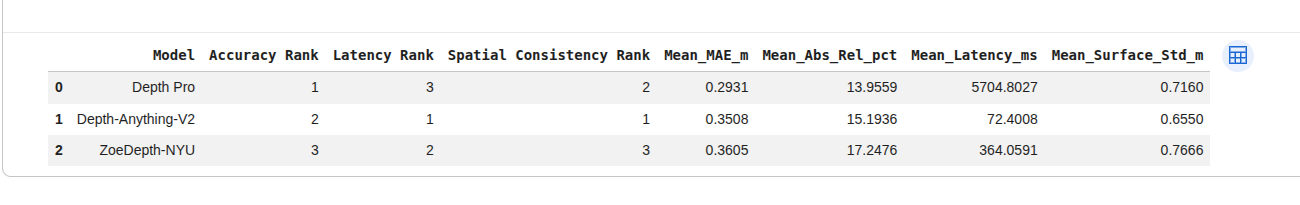

# Interpretation
This study compared Depth Pro, Depth-Anything-V2, and ZoeDepth-NYU for monocular metric depth estimation using the same 59 synchronized RGB–depth samples and a common evaluation procedure.

Depth Pro achieved the highest depth accuracy, obtaining the lowest mean MAE of 0.2931 m and the lowest mean Abs Rel of 13.96%. However, this accuracy came with a substantial computational cost: its mean inference latency was approximately 5705 ms per image, making it unsuitable for real-time robotic applications under the tested configuration.

Depth-Anything-V2 provided the strongest accuracy–latency trade-off. It achieved the lowest latency at approximately 72.4 ms per image, corresponding to roughly 13.8 FPS, while maintaining competitive accuracy with a mean MAE of 0.3508 m and mean Abs Rel of 15.19%. It therefore represents the most practical choice among the evaluated models when real-time or near-real-time inference is required.

ZoeDepth-NYU ranked third in accuracy and second in latency, with a mean MAE of 0.3605 m, mean Abs Rel of 17.25%, and mean latency of 364.1 ms per image. Although substantially faster than Depth Pro, its latency remains considerably higher than Depth-Anything-V2 while providing slightly worse accuracy in this evaluation.

Overall, the results demonstrate a clear accuracy–computational-cost trade-off. Depth Pro provides the best metric-depth accuracy, whereas Depth-Anything-V2 provides the best balance between accuracy and inference speed. For real-time robotics, autonomous navigation, and edge deployment, Depth-Anything-V2 is therefore the most suitable model among the three evaluated under the tested conditions. For applications where inference speed is less important and maximum depth accuracy is the priority, Depth Pro is the stronger candidate.

# Limitations and Reproducibility Notes

1. The dataset is **59 real RGB-depth pairs** captured with an Intel RealSense camera, limited to a single indoor lab environment.
2. The RealSense depth map is itself a sensor measurement and can contain noise or invalid readings (excluded via the zero-pixel mask), so it is not a perfect reference.
3. RealSense depth quality degrades on reflective, transparent, distant, and low-texture surfaces, which propagates into every metric computed on affected frames.
4. Accurate RGB-depth alignment is required for the pixel-wise metrics to be meaningful; misalignment would bias MAE/RMSE/Abs Rel.
5. All three models should be benchmarked in the same runtime session and on the same hardware when reporting latency.
6. GPU frequency, thermal throttling, background processes, CUDA/cuDNN versions, and model caching can affect latency.
7. The benchmark includes model-specific preprocessing because each model requires its official input transformation. Image retrieval and evaluation are common.
8. Depth Pro uses its official preprocessing/inference API; Depth-Anything-V2 and ZoeDepth use their Hugging Face processor/model APIs.
9. Because each of the 59 frames is now a unique real capture rather than repeated shots at a fixed distance, the earlier notion of "repeatability across repeated captures" no longer applies; valid-pixel coverage is reported instead.
10. For publication-level benchmarking, use a larger, multi-scene dataset and report additional established dense-depth metrics (e.g. threshold accuracy δ).


# Conclusion

The final controlled pipeline is:

**59 real RealSense RGB-depth pairs → Depth-Anything-V2 / ZoeDepth / Depth Pro → dense predicted metric depth → pixel-wise comparison against dense RealSense ground truth → same statistical metrics → same visual inspection → same latency benchmark → direct model comparison**

The central research question is therefore:

> **Under identical RGB inputs and identical dense RealSense ground truth, which monocular metric-depth model provides the best combination of pixel-wise accuracy, spatial consistency, valid-pixel coverage, and computational latency?**

This is a reproducible foundation for the three-model comparison. It can be extended to more scenes and more RealSense captures by adding further RGB-depth pairs to the same `color/` and `depth/` folder structure, without changing the evaluation logic.


## Persistence Architecture

**Environment 1:** image retrieval → Depth-Anything-V2 → ZoeDepth → measurements → `metric_depth_experiment_state.pkl`

**Runtime restart:** Python objects are cleared, but the pickle file remains in `/content`.

**Environment 2:** restore pickle → install/load Depth Pro → evaluate Depth Pro → merge all three models → save `three_model_metric_depth_complete.pkl`.

This avoids rerunning the first two models solely because the Depth Pro dependency stack requires a runtime restart.
